CUDA not available, using 4 CPUs
Found 120 tasks to solve
Running in CPU mode with limited tasks...
Processing 0934a4d8...
Processing 135a2760...
Processing 136b0064...
Processing 13e47133...
Processing 142ca369...
120 tasks solved.
10 steps taken.
Total time: 350.2 seconds
Running visualization...

VISUALIZING ARC SOLUTION RESULTS
Found submission file: submission.json
Loaded submission with 120 tasks

Found 122 total predictions to visualize
Showing 10 of 122 prediction samples

Task: 0934a4d8 - Test #1


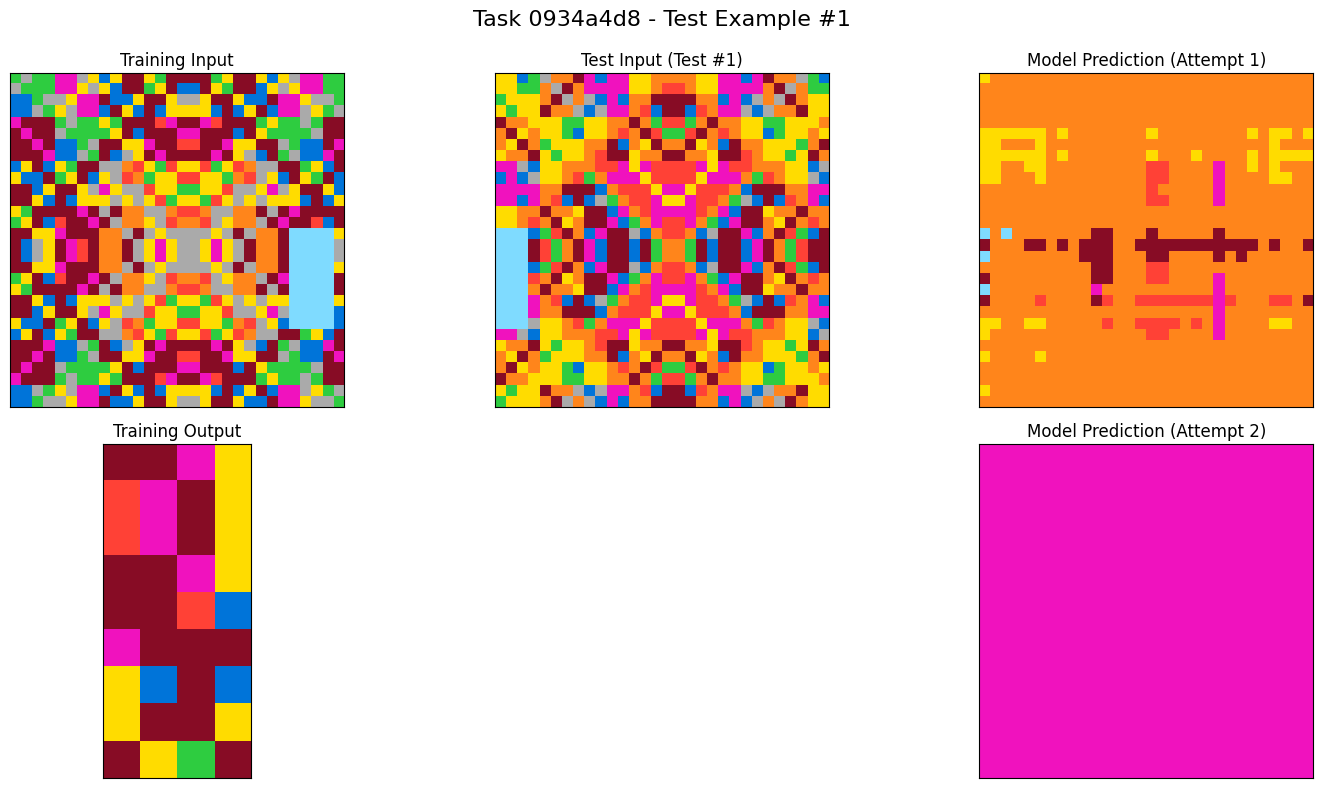


Task: 135a2760 - Test #1


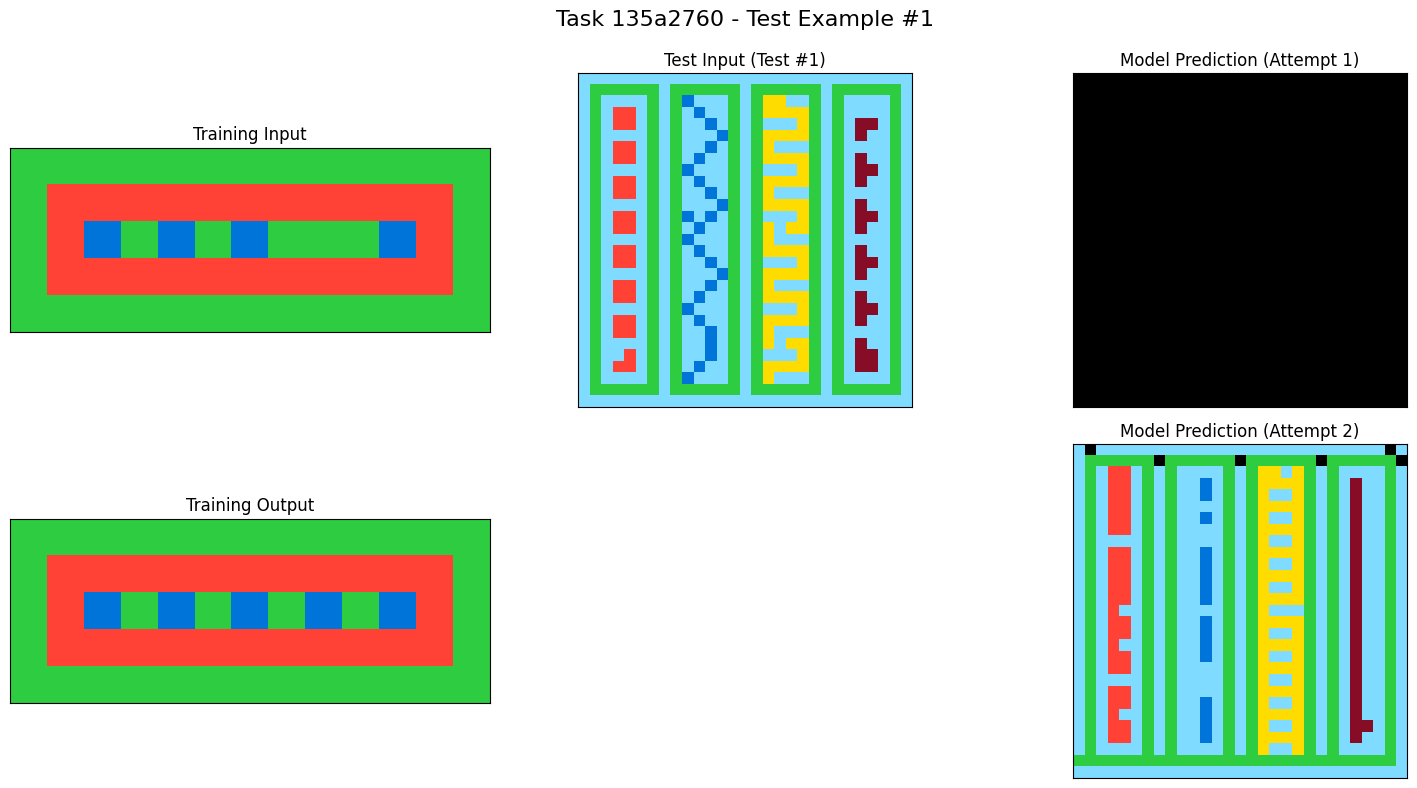


Task: 136b0064 - Test #1


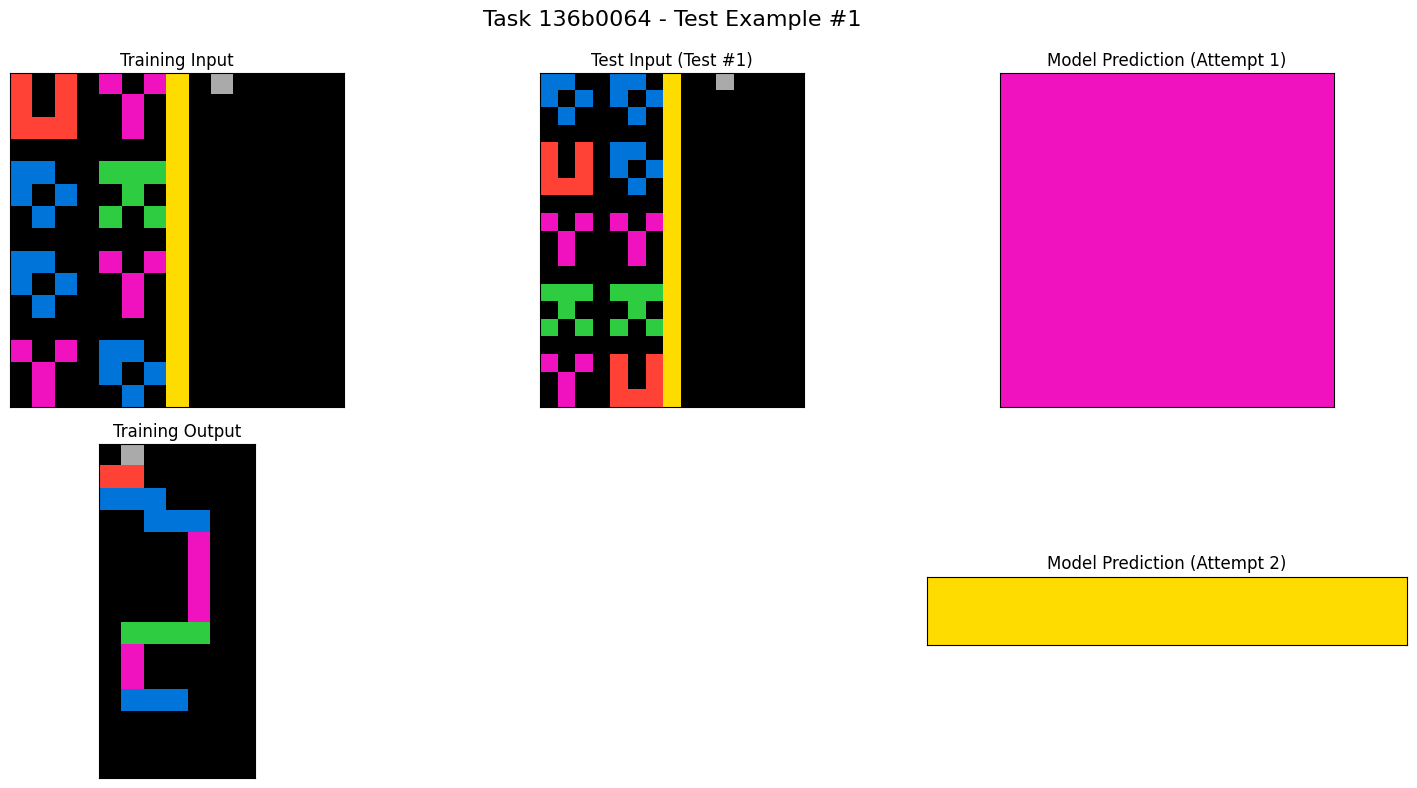


Task: 13e47133 - Test #1


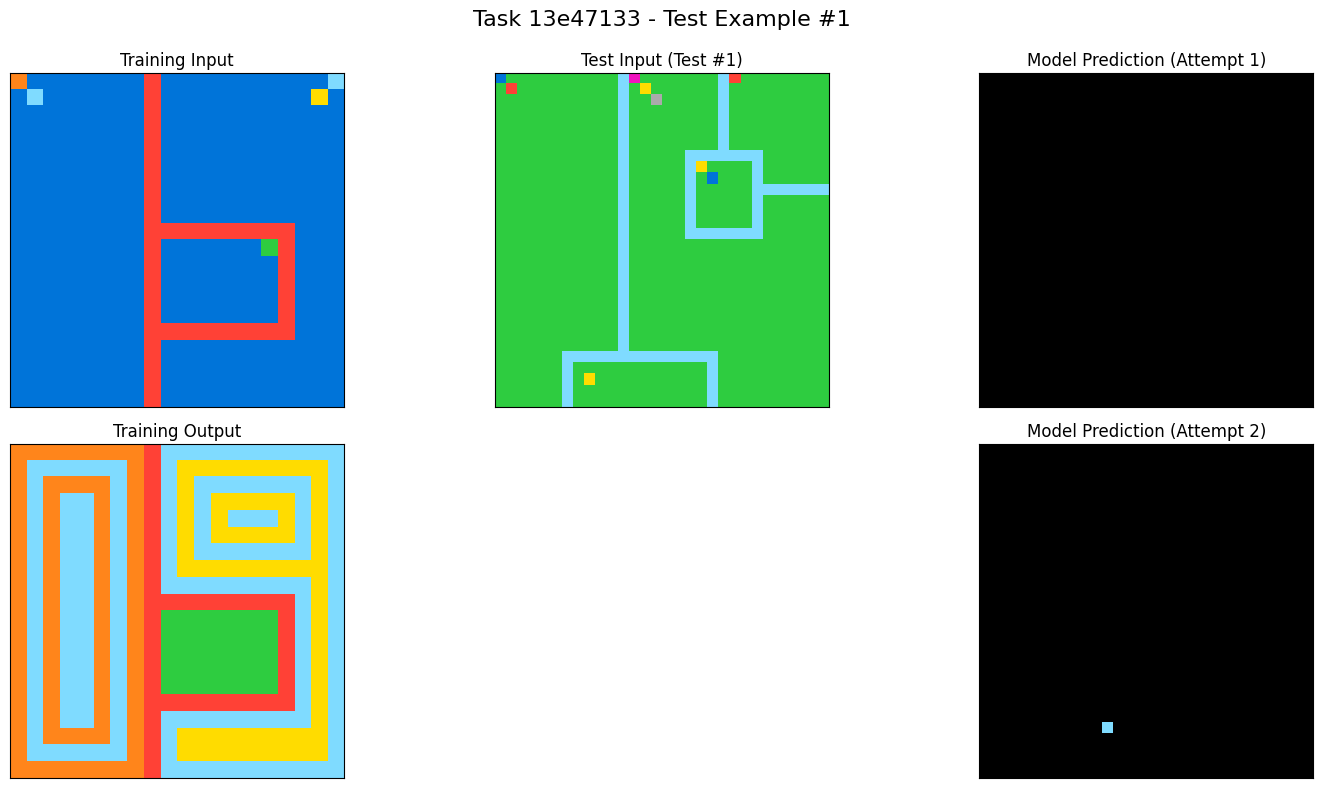


Task: 13e47133 - Test #2


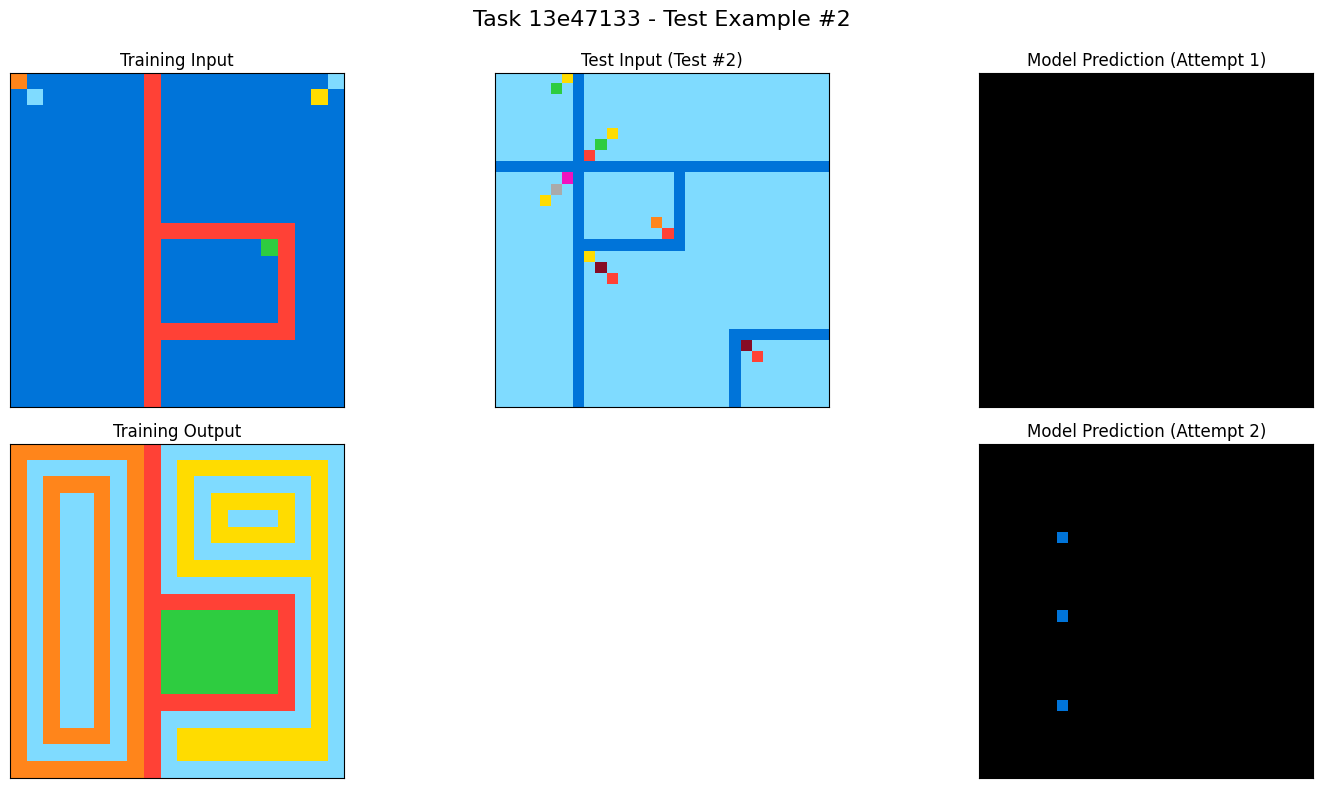


Task: 142ca369 - Test #1


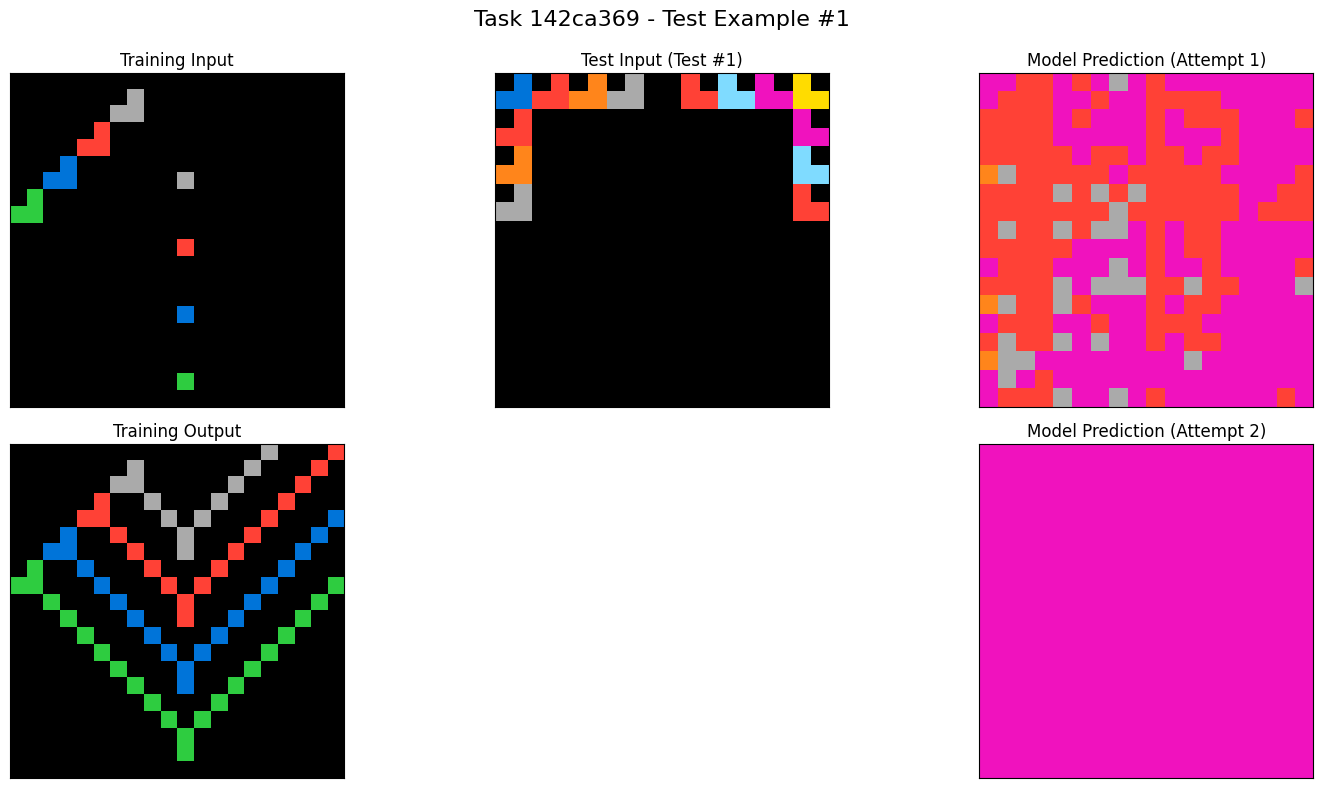


Task: 142ca369 - Test #2


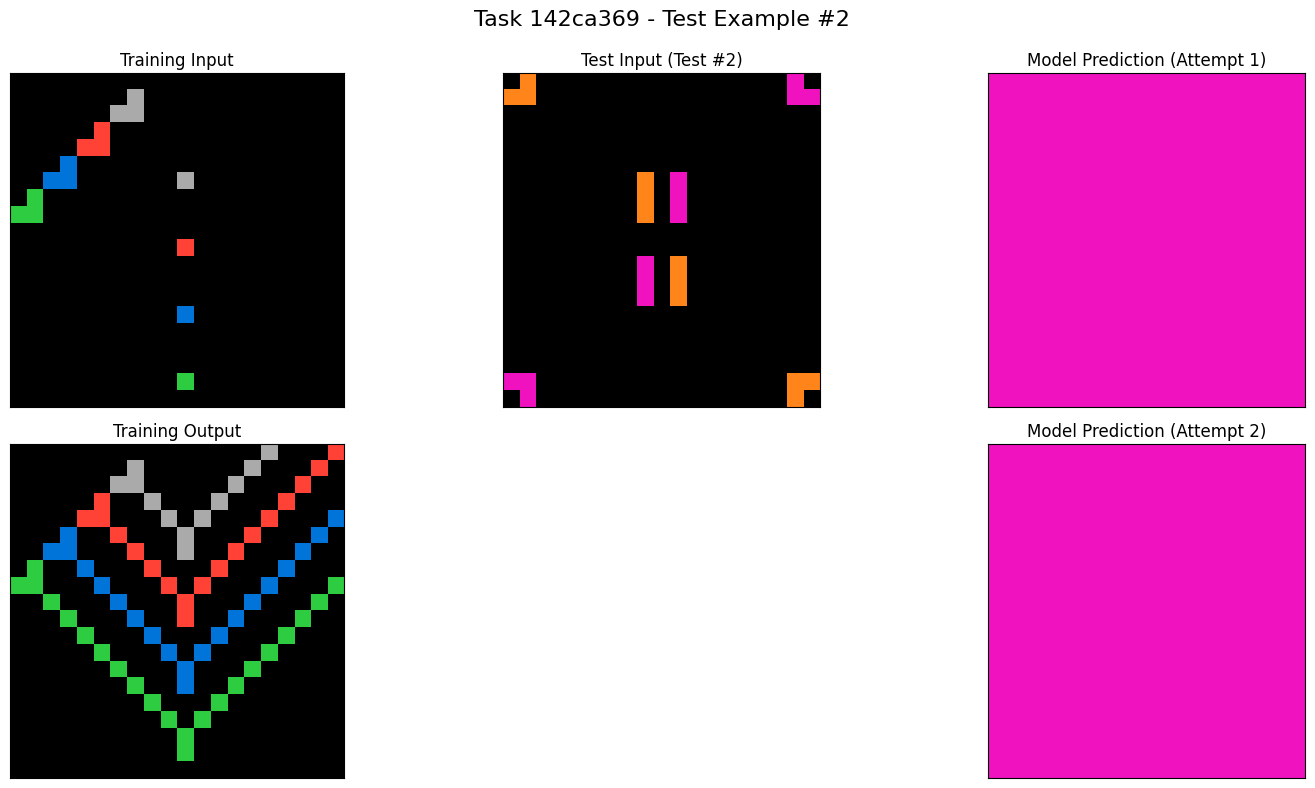


Task: 16b78196 - Test #1
  Skipping visualization for Task 16b78196 - Test #1 (all predictions are zeros)

Task: 16de56c4 - Test #1
  Skipping visualization for Task 16de56c4 - Test #1 (all predictions are zeros)

Task: 1818057f - Test #1
  Skipping visualization for Task 1818057f - Test #1 (all predictions are zeros)

Visualized 7 inference results (skipped 3 with all-zero predictions)


In [1]:
import random
import numpy as np
import torch
import os
import sys
import time
import json
import importlib
import multiprocessing
from multiprocessing import Pool
import gc
import itertools
import matplotlib.pyplot as plt
from matplotlib import colors
import tqdm
import traceback

GLOBAL_SEED = 42
fake_mode = not os.getenv('KAGGLE_IS_COMPETITION_RERUN')

def set_all_seeds(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

np.random.seed(0)
torch.manual_seed(0)
torch.set_default_dtype(torch.float32)
if torch.cuda.is_available():
    torch.set_default_device('cuda')

NUM_DIMENSIONS = 5 

class MultiTensorSystem:
    def __init__(self, n_examples, n_colors, n_x, n_y, task):
        self.n_examples = n_examples
        self.n_colors = n_colors
        self.n_directions = 8
        self.n_x = n_x
        self.n_y = n_y
        self.task = task
        self.dim_lengths = [self.n_examples, self.n_colors,
                            self.n_directions, self.n_x, self.n_y]
    
    def dims_valid(self, dims):
        if (dims[3] or dims[4]) and not dims[0]:
            return False
        if sum(dims[1:]) == 0:
            return False
        return True

    def shape(self, dims, extra_dim=None):
        shape = []
        for dim_index, length in enumerate(self.dim_lengths):
            if dims[dim_index]:
                shape.append(length)
        if extra_dim is not None:
            shape.append(extra_dim)
        return shape

    def _generate_dims_combinations(self):
        for i in range(2 ** NUM_DIMENSIONS):
            dims = [(i >> bit) & 1 for bit in range(NUM_DIMENSIONS)]
            yield dims

    def __iter__(self):
        for dims in self._generate_dims_combinations():
            if self.dims_valid(dims):
                yield dims

    def _make_multitensor(self, default, index):
        if index == NUM_DIMENSIONS:
            return default
        return [self._make_multitensor(default, index+1) for _ in range(2)]

    def make_multitensor(self, default=None):
        return MultiTensor(self._make_multitensor(default, 0), self)


class MultiTensor:
    def __init__(self, data, multitensor_system):
        self.data = data
        self.multitensor_system = multitensor_system

    def __getitem__(self, dims):
        d = self.data
        for dim_val in dims:
            d = d[dim_val]
        return d

    def __setitem__(self, dims, value):
        d = self.data
        for dim_val in dims[:-1]:
            d = d[dim_val]
        d[dims[-1]] = value


def multify(fn):
    def wrapper(*args, **kwargs):
        multitensor_system = None
        multi_mode = False

        for arg in args:
            if isinstance(arg, MultiTensor):
                multi_mode = True
                multitensor_system = arg.multitensor_system
        if not multi_mode:
            for value in kwargs.values():
                if isinstance(value, MultiTensor):
                    multi_mode = True
                    multitensor_system = value.multitensor_system
                    break

        if not multi_mode:
            return fn(None, *args, **kwargs)

        def iterate_and_assign(multitensor_system, result_data):
            for dims in multitensor_system:
                new_args = []
                for arg in args:
                    if isinstance(arg, MultiTensor):
                        new_args.append(arg[dims])
                    else:
                        new_args.append(arg)
                new_kwargs = {}
                for key, value in kwargs.items():
                    if isinstance(value, MultiTensor):
                        new_kwargs[key] = value[dims]
                    else:
                        new_kwargs[key] = value
                output = fn(dims, *new_args, **new_kwargs)
                result_data[dims] = output

        result_data = multitensor_system.make_multitensor()
        iterate_and_assign(multitensor_system, result_data)

        return result_data

    return wrapper
    
class Task:
    def __init__(self, task_name, problem, solution):
        self.task_name = task_name
        self.n_train = len(problem['train'])
        self.n_test = len(problem['test'])
        self.n_examples = self.n_train + self.n_test
        self.unprocessed_problem = problem

        self.shapes = self._collect_problem_shapes(problem)
        self._predict_solution_shapes()
        self._construct_multitensor_system(problem)
        self._compute_mask()
        self._create_problem_tensor(problem)

        self.solution = self._create_solution_tensor(solution) if solution else None

    def _collect_problem_shapes(self, problem):
        shapes = []
        for split_name in ['train', 'test']:
            for example in problem[split_name]:
                in_shape = list(np.array(example['input']).shape)
                out_shape = list(np.array(example['output']).shape) if 'output' in example else None
                shapes.append([in_shape, out_shape])
        return shapes

    def _predict_solution_shapes(self):
        self.in_out_same_size = all(tuple(inp) == tuple(out) for inp, out in self.shapes[:self.n_train])
        self.all_in_same_size = len({tuple(shape[0]) for shape in self.shapes}) == 1
        self.all_out_same_size = len({tuple(shape[1]) for shape in self.shapes if shape[1]}) == 1

        if self.in_out_same_size:
            for shape in self.shapes[self.n_train:]:
                shape[1] = shape[0]
        elif self.all_out_same_size:
            default_shape = self.shapes[0][1]
            for shape in self.shapes[self.n_train:]:
                shape[1] = default_shape
        else:
            max_x, max_y = self._get_max_dimensions()
            for shape in self.shapes[self.n_train:]:
                shape[1] = [max_x, max_y]

    def _get_max_dimensions(self):
        max_x, max_y = 0, 0
        for in_out_pair in self.shapes:
            for shape in in_out_pair:
                if shape:
                    max_x = max(max_x, shape[0])
                    max_y = max(max_y, shape[1])
        return max_x, max_y

    def _construct_multitensor_system(self, problem):
        self.n_x = max(shape[i][0] for shape in self.shapes for i in range(2))
        self.n_y = max(shape[i][1] for shape in self.shapes for i in range(2))

        colors = {color 
                  for split in ['train', 'test']
                  for example in problem[split] 
                  for grid in [example['input'], example.get('output', [])]
                  for row in grid
                  for color in row}
        colors.add(0)
        self.colors = list(sorted(colors))
        self.n_colors = len(self.colors) - 1
        self.multitensor_system = MultiTensorSystem(
            self.n_examples, self.n_colors, self.n_x, self.n_y, self
        )

    def _create_problem_tensor(self, problem):
        self.problem = np.zeros((self.n_examples, self.n_colors + 1, self.n_x, self.n_y, 2))
        
        for subsplit, n_examples in [('train', self.n_train), ('test', self.n_test)]:
            for example_num, example in enumerate(problem[subsplit]):
                new_example_num = example_num if subsplit == 'train' else self.n_train + example_num

                for mode in ('input', 'output'):
                    if subsplit == 'test' and mode == 'output':
                        continue

                    grid = self._create_grid_tensor(
                        example.get(mode, np.zeros(self.shapes[new_example_num][1]))
                    )
                    mode_num = 0 if mode == 'input' else 1
                    self.problem[new_example_num, :, :grid.shape[1], :grid.shape[2], mode_num] = grid

        device = torch.get_default_device() if torch.cuda.is_available() else 'cpu'
        self.problem = torch.from_numpy(np.argmax(self.problem, axis=1)).to(device)

    def _create_grid_tensor(self, grid):
        return np.array([
            [[1 if self.colors.index(color) == ref_color else 0
              for color in row]
             for row in grid]
            for ref_color in range(self.n_colors + 1)
        ])

    def _create_solution_tensor(self, solution):
        solution_tensor = np.zeros((self.n_test, self.n_colors + 1, self.n_x, self.n_y))
        solution_tuple = ()

        for example_num, grid in enumerate(solution):
            solution_tuple += (tuple(map(tuple, grid)),)
            grid_tensor = self._create_grid_tensor(grid)
            min_x, min_y = min(grid_tensor.shape[1], self.n_x), min(grid_tensor.shape[2], self.n_y)
            solution_tensor[example_num, :, :min_x, :min_y] = grid_tensor[:, :min_x, :min_y]

        self.solution_hash = hash(solution_tuple)
        device = torch.get_default_device() if torch.cuda.is_available() else 'cpu'
        return torch.from_numpy(np.argmax(solution_tensor, axis=1)).to(device)

    def _compute_mask(self):
        self.masks = np.zeros((self.n_examples, self.n_x, self.n_y, 2))

        for example_num, (in_shape, out_shape) in enumerate(self.shapes):
            for mode_num, shape in enumerate([in_shape, out_shape]):
                if shape:
                    x_mask = np.arange(self.n_x) < shape[0]
                    y_mask = np.arange(self.n_y) < shape[1]
                    self.masks[example_num, :, :, mode_num] = np.outer(x_mask, y_mask)

        device = torch.get_default_device() if torch.cuda.is_available() else 'cpu'
        self.masks = torch.from_numpy(self.masks).to(torch.get_default_dtype()).to(device)


def preprocess_tasks(split, task_nums_or_task_names):
    # Fixed file paths for Kaggle environment
    challenges_path = f'../input/arc-prize-2025/arc-agi_{split}_challenges.json'
    solutions_path = f'../input/arc-prize-2025/arc-agi_{split}_solutions.json'
    
    # Fallback for local development
    if not os.path.exists(challenges_path):
        challenges_path = f'dataset/arc-agi_{split}_challenges.json'
        solutions_path = f'dataset/arc-agi_{split}_solutions.json'
    
    with open(challenges_path, 'r') as f:
        problems = json.load(f)

    solutions = None
    if split != "test" and os.path.exists(solutions_path):
        with open(solutions_path, 'r') as f:
            solutions = json.load(f)
    
    task_names = list(problems.keys())
    
    return [Task(task_name,
                 problems[task_name],
                 solutions.get(task_name) if solutions else None)
            for task_name in task_names
            if task_name in task_nums_or_task_names or task_names.index(task_name) in task_nums_or_task_names]

class Initializer:
    def __init__(self, multitensor_system, channel_dim_fn):
        self.multitensor_system = multitensor_system
        self.channel_dim_fn = channel_dim_fn
        self.weights_list = []

    def initialize_zeros(self, dims, shape):
        if callable(shape):
            shape = shape(dims)
        zeros = torch.zeros(shape, requires_grad=True)
        self.weights_list.append(zeros)
        return zeros

    def initialize_linear(self, dims, shape):
        if callable(shape):
            shape = shape(dims)
        n_in, n_out = shape

        if callable(n_in):
            n_in = n_in(dims)
        if callable(n_out):
            n_out = n_out(dims)

        scale = 1 / np.sqrt(n_in)
        weight = scale * torch.randn(n_in, n_out)
        bias = scale * torch.randn(n_out)
        weight.requires_grad = True
        bias.requires_grad = True

        self.weights_list.extend([weight, bias])
        return [weight, bias]

    def initialize_residual(self, dims, n_in, n_out):
        linear_1 = self.initialize_linear(dims, [self.channel_dim_fn, n_in])
        linear_2 = self.initialize_linear(dims, [n_out, self.channel_dim_fn])
        return [linear_1, linear_2]

    def initialize_posterior(self, dims, channel_dim):
        if callable(channel_dim):
            channel_dim = channel_dim(dims)

        shape = self.multitensor_system.shape(dims, channel_dim)
        mean = 0.01 * torch.randn(shape)
        mean.requires_grad=True
        local_capacity_adjustment = self.initialize_zeros(dims, shape)

        self.weights_list.append(mean)
        return [mean, local_capacity_adjustment]

    def initialize_direction_share(self, dims, _):
        channel_dim_fn = self.channel_dim_fn
        return [[self.initialize_linear(dims, [channel_dim_fn, channel_dim_fn]) for _ in range(8)] for _ in range(8)]

    def initialize_head(self):
        dims = [1, 1, 0, 1, 1]
        head_weights = self.initialize_linear(dims, [self.channel_dim_fn(dims), 2])

        head_weights[0].requires_grad = False
        head_weights[0] = torch.stack([head_weights[0][..., 0]] * 2, dim=-1)
        head_weights[0].requires_grad = True

        self.weights_list[-2] = head_weights[0]
        return head_weights

    def initialize_multizeros(self, shape):
        return multify(self.initialize_zeros)(
            self.multitensor_system.make_multitensor(default=shape)
        )

    def initialize_multilinear(self, shape):
        return multify(self.initialize_linear)(
            self.multitensor_system.make_multitensor(default=shape)
        )

    def initialize_multiresidual(self, n_in, n_out):
        return multify(self.initialize_residual)(
            n_in, self.multitensor_system.make_multitensor(default=n_out)
        )

    def initialize_multiposterior(self, decoding_dim):
        return multify(self.initialize_posterior)(
            self.multitensor_system.make_multitensor(default=decoding_dim)
        )

    def initialize_multidirection_share(self):
        return multify(self.initialize_direction_share)(
            self.multitensor_system.make_multitensor()
        )

    def symmetrize_xy(self, multiweights):
        for dims in self.multitensor_system:
            if dims[3] == 0 and dims[4] == 1:
                multiweights[dims] = multiweights[dims[:3] + [1, 0]]

    def symmetrize_direction_sharing(self, multiweights):
        for dims in self.multitensor_system:
            for dir1 in range(8):
                for dir2 in range(8):
                    from_dims = dims
                    from_dir1, from_dir2 = dir1, dir2
                    if dims[3] + dims[4] == 1:
                        from_dims = dims[:3] + [1, 0]
                        if dims[4] == 1:
                            from_dir1 = (2 + from_dir1) % 8
                            from_dir2 = (2 + from_dir2) % 8

                        if from_dir1 > 4 or (from_dir1 in {0, 4} and from_dir2 > 4):
                            from_dir1 = (8 - from_dir1) % 8
                            from_dir2 = (8 - from_dir2) % 8

                        if 2 < from_dir1 < 6 or (from_dir1 in {2, 6} and 2 < from_dir2 < 6):
                            from_dir1 = (4 - from_dir1) % 8
                            from_dir2 = (4 - from_dir2) % 8
                    else:
                        rotation = (from_dir1 // 2) * 2
                        from_dir1 = (from_dir1 - rotation) % 8
                        from_dir2 = (from_dir2 - rotation) % 8

                        if (from_dir2 - from_dir1) % 8 > 4:
                            from_dir2 = (8 + 2 * from_dir1 - from_dir2) % 8

                    multiweights[dims][dir1][dir2] = multiweights[from_dims][from_dir1][from_dir2]

@multify
def normalize(dims, x, debias=True):
    all_but_last = list(range(len(x.shape)-1))
    if debias:
        x = x - torch.mean(x, dim=all_but_last)
    x = x / torch.sqrt(1e-8+torch.mean(x**2, dim=all_but_last))
    return x

@multify
def affine(dims, x, weight, use_bias=False):
    x = torch.matmul(x, weight[0])
    if use_bias:
        x = x + weight[1]
    return x

def add_residual(layer):
    def layer_with_residual(dims, x, residual_weights, *args,
                            use_bias=False, pre_norm=False, post_norm=False, **kwargs):
        if pre_norm:
            z = normalize(x)
        z = affine(x, residual_weights[0], use_bias=use_bias)
        z = layer(dims, z, *args, **kwargs)
        if post_norm:
            z = normalize(z)
        z = affine(z, residual_weights[1], use_bias=use_bias)
        return x + z
    return layer_with_residual

def channel_layer(target_capacity, posterior):
    mean, local_capacity_adjustment = posterior

    all_but_last_dim = tuple(range(len(mean.shape)-1))
    dimensionality = 1
    for axis_length in mean.shape:
        dimensionality *= axis_length
    min_capacity = 0.5
    init_capacity = 10000
    min_capacity = torch.tensor(min_capacity)
    init_capacity = torch.tensor(init_capacity)

    target_capacity = 10*target_capacity 
    desired_global_capacity = torch.exp(target_capacity)*init_capacity + min_capacity
    output_scaling = 1-torch.exp(-desired_global_capacity / dimensionality * 2)

    local_capacity_adjustment = (target_capacity + 
                                 local_capacity_adjustment - 
                                 torch.mean(local_capacity_adjustment, dim=all_but_last_dim))
    desired_local_capacity = torch.exp(local_capacity_adjustment)*init_capacity + min_capacity
    
    noise_std = torch.exp(-desired_local_capacity / dimensionality)
    noise_var = noise_std**2
    stable_sqrt1memx = lambda x: torch.where(x>20, 1, torch.sqrt(1-torch.exp(-x)))
    signal_std = stable_sqrt1memx(desired_local_capacity / dimensionality * 2)
    signal_var = 1-noise_var

    normalized_mean = mean - torch.mean(mean, dim=all_but_last_dim)
    normalized_mean = normalized_mean / torch.sqrt(torch.mean(normalized_mean**2+1e-8, dim=all_but_last_dim))

    z = signal_std*normalized_mean + noise_std*torch.randn(normalized_mean.shape)
    z = output_scaling*z  
    
    KL = 0.5*(noise_var + signal_var*normalized_mean**2 - 1) + desired_local_capacity/dimensionality
    return z, KL

def decode_latents(target_capacities, decode_weights, multiposteriors):
    KL_amounts = []
    KL_names = []

    @multify
    def decode_latents_(dims, target_capacity, decode_weight, posterior):
        z, KL = channel_layer(target_capacity, posterior)
        x = affine(z, decode_weight, use_bias=True)
        KL_amounts.append(KL)
        KL_names.append(str(dims))
        return x
    x = decode_latents_(target_capacities, decode_weights, multiposteriors)
    return x, KL_amounts, KL_names


def share_direction(residual, share_weights, direction):
    down_project_weights = multify(lambda dims, weights: weights[0])(share_weights)
    up_project_weights = multify(lambda dims, weights: weights[1])(share_weights)

    multitensor_system = residual.multitensor_system

    x = affine(residual, down_project_weights, use_bias=False)

    if direction == 1: 
        def share(dims, _):
            lower_xs = []
            for lower_dims in multitensor_system:
                if all([lower_naxes <= naxes for lower_naxes, naxes in zip(lower_dims, dims)]):
                    lower_x = x[lower_dims]
                    for dim, (lower_naxes, naxes) in enumerate(zip(lower_dims, dims)):
                        if lower_naxes < naxes:
                            axis = sum(dims[:dim], 0)
                            lower_x = torch.unsqueeze(lower_x, axis)
                    lower_xs.append(lower_x)
            return sum(lower_xs)
    else:
        def share(dims, _):
            higher_xs = []
            for higher_dims in multitensor_system:
                if all([higher_naxes >= naxes for higher_naxes, naxes in zip(higher_dims, dims)]):
                    higher_x = x[higher_dims]
                    for dim, (higher_naxes, naxes) in reversed(list(enumerate(zip(higher_dims, dims)))):
                        if higher_naxes > naxes:
                            axis = sum(higher_dims[:dim], 0)
                            if (x.multitensor_system.task.in_out_same_size or x.multitensor_system.task.all_out_same_size) and dim==3:  # be careful aggregating the x axis
                                masks = x.multitensor_system.task.masks
                                masks = 1-(1-masks[...,0])*(1-masks[...,1])
                                for i in range(sum(higher_dims[1:3])):
                                    masks = masks[:,None,...]
                                if dims[4] == 0: 
                                    masks = masks[...,0]
                                masks = masks[...,None] 
                                higher_x = torch.sum(higher_x*masks, dim=axis) / (torch.sum(masks, dim=axis)+1e-4)
                            elif (x.multitensor_system.task.in_out_same_size or x.multitensor_system.task.all_out_same_size) and dim==4:  # be careful aggregating the y axis
                                masks = x.multitensor_system.task.masks
                                masks = 1-(1-masks[...,0])*(1-masks[...,1])
                                for i in range(sum(higher_dims[1:3])): 
                                    masks = masks[:,None,...]
                                if higher_dims[3] == 0:  
                                    masks = masks[...,0,:]
                                masks = masks[...,None] 
                                higher_x = torch.sum(higher_x*masks, dim=axis) / (torch.sum(masks, dim=axis)+1e-4)
                            else:
                                higher_x = torch.mean(higher_x, dim=axis)
                    higher_xs.append(higher_x)
            return sum(higher_xs)
    x = multify(share)(x)
    x = normalize(x)
    x = affine(x, up_project_weights, use_bias=False)
    residual = multify(lambda dims, x, y: x+y)(residual, x)
    return residual

def share_up(residual, share_up_weights):
    return share_direction(residual, share_up_weights, 1)

def share_down(residual, share_down_weights):
    return share_direction(residual, share_down_weights, -1)


def only_do_for_certain_shapes(*shapes):
    def decorator(fn):
        def filtered_fn(dims, x, *args, **kwargs):
            if tuple(dims) in shapes:
                return fn(dims, x, *args, **kwargs)
            else:
                return x
        return filtered_fn
    return decorator


@multify
@add_residual
def softmax(dims, x):
    axes = list(range(sum(dims)))
    if dims[0]==1:
        axes.pop(0)
    subsets_of_axes = []
    for subset_size in range(1, len(axes)+1):
        subsets_of_axes = subsets_of_axes + list(itertools.combinations(axes, subset_size))
    softmaxxes = []
    for subset in subsets_of_axes:
        offsets = torch.amax(x, dim=subset, keepdim=True)
        softmax = torch.exp(x-offsets)
        softmax = softmax / torch.sum(softmax, dim=subset, keepdim=True)
        softmaxxes.append(softmax)
    return torch.cat(softmaxxes, dim=-1)


def make_directional_layer(fn, diagonal_fn):
    def directional_layer(dims, x, masks):
        masks = 1-(1-masks[...,0])*(1-masks[...,1])
        if dims[4]==0:
            masks = masks[:,:,0]
        if dims[3]==0:
            masks = masks[:,0,...]
        for i in range(sum(dims[1:3])):
            masks = masks[:,None,...]
        masks = masks[...,None]
        x = x*masks

        n_directions = dims[3]+dims[4]
        direction_dim = sum(dims[:2])

        zero_tensor = torch.zeros_like(torch.select(x, direction_dim, 0))

        result_tensors = []
        for channel_split in range(2):
            result_list = []
            for direction_split in range(2):
                for direction_ind in range(4):
                    if direction_ind % 2 == 0:
                        cardinal_direction_ind = int(direction_ind//2)
                        if dims[3+cardinal_direction_ind]>0:
                            x_slice = torch.select(x, direction_dim, 4*direction_split+direction_ind)
                            x_slice = x_slice[...,channel_split::2]
                            masks_flipped = torch.select(masks, direction_dim, 0)
                            if direction_split + channel_split == 1:
                                x_slice = torch.flip(x_slice, [direction_dim+cardinal_direction_ind])
                                masks_flipped = torch.flip(masks_flipped, [direction_dim+cardinal_direction_ind])
                            result = fn(x_slice, direction_dim+cardinal_direction_ind, masks_flipped)
                            if direction_split + channel_split == 1:
                                result = torch.flip(result, [direction_dim+cardinal_direction_ind])
                        else:
                            result = zero_tensor
                    else:
                        if dims[3] == 1 and dims[4] == 1:
                            diagonal_direction_ind = int(direction_ind//2)  # 0 for x+y, 1 for y-x
                            x_slice = torch.select(x, direction_dim, 4*direction_split+direction_ind)
                            x_slice = x_slice[...,channel_split::2]
                            masks_flipped = torch.select(masks, direction_dim, 0)
                            if (direction_split + channel_split + diagonal_direction_ind) % 2 == 1:
                                x_slice = torch.flip(x_slice, [direction_dim])
                                masks_flipped = torch.flip(masks_flipped, [direction_dim])
                            if direction_split + channel_split == 1:
                                x_slice = torch.flip(x_slice, [direction_dim+1])
                                masks_flipped = torch.flip(masks_flipped, [direction_dim+1])
                            result = diagonal_fn(x_slice, direction_dim, direction_dim+1, masks_flipped)
                            if (direction_split + channel_split + diagonal_direction_ind) % 2 == 1:
                                result = torch.flip(result, [direction_dim])
                            if direction_split + channel_split == 1:
                                result = torch.flip(result, [direction_dim+1])
                        else:
                            result = zero_tensor
                    result_list.append(result)
            result_list = torch.stack(result_list, dim=direction_dim)
            result_tensors.append(result_list)
        return torch.cat(result_tensors, dim=-1)
    return directional_layer

def cummax_(x, dim, masks):
    masks = 1e3*(1-masks)
    max_ = torch.max(x-masks, dim=dim, keepdim=True)[0] + masks + 1e-3
    min_ = torch.min(x+masks, dim=dim, keepdim=True)[0] - masks - 1e-3
    x = torch.cummax(x-masks, dim=dim)[0] + masks
    return (x - min_) / (max_-min_) * 2 - 1

def diagonal_cummax_(x, dim1, dim2, masks):
    masks_ = 1e3*(1-masks)
    min_dim = min(x.shape[dim1], x.shape[dim2])
    n_iters = int(np.ceil(np.log2(min_dim)))
    max_x = x - masks_
    for sign in (1, -1):
        for i in range(n_iters):
            shift_amount = sign*2**i
            shifted_x = diagonal_shift_(max_x, dim1, dim2, masks_, shift_amount=shift_amount, pad_value=-1e3)
            max_x = torch.max(max_x, shifted_x)
        if sign == 1:
            cummax_x = max_x + masks_
    max_x = max_x + masks_
    min_x = x + masks_
    for sign in (1, -1):
        for i in range(n_iters):
            shift_amount = sign*2**i
            shifted_x = diagonal_shift_(min_x, dim1, dim2, masks_, shift_amount=shift_amount, pad_value=1e3)
            min_x = torch.min(min_x, shifted_x)
    min_x = min_x - masks_
    return ((cummax_x - min_x) / (max_x-min_x+1e-5) * 2 - 1)*masks

cummax = multify(
         only_do_for_certain_shapes((1,1,1,1,1), (1,0,1,1,1))(
         add_residual(
         make_directional_layer(
         cummax_, diagonal_cummax_
         ))))

def shift_(x, dim, masks):
    padding = torch.zeros_like(torch.narrow(x, dim, 0, 1))
    narrowed = torch.narrow(x, dim, 0, x.shape[dim]-1)
    return torch.cat([padding, narrowed], dim=dim)

def diagonal_shift_(x, dim1, dim2, masks, shift_amount=1, pad_value=0):
    for dim in (dim1, dim2):
        padding = pad_value+torch.zeros_like(torch.narrow(x, dim, 0, abs(shift_amount)))
        if shift_amount >= 0:
            narrowed = torch.narrow(x, dim, 0, x.shape[dim]-shift_amount)
            x = torch.cat([padding, narrowed], dim=dim)
        else:
            narrowed = torch.narrow(x, dim, -shift_amount, x.shape[dim]+shift_amount)
            x = torch.cat([narrowed, padding], dim=dim)
    return x

shift = multify(
        only_do_for_certain_shapes((1,1,1,1,1), (1,0,1,1,1))(
        add_residual(
        make_directional_layer(
        shift_, diagonal_shift_
        ))))

directional_dims = [(i,j,1,k,l) for i in range(2) for j in range(2) for k in range(2) for l in range(2)]

@multify
@only_do_for_certain_shapes(*directional_dims)
def direction_share(dims, x, weights, pre_norm=True, use_bias=False):
    z = normalize(x) if pre_norm else x

    n_directions = dims[3] + dims[4]
    direction_dim = -2 - n_directions

    x_list = list(torch.unbind(x, dim=direction_dim))
    z_list = list(torch.unbind(z, dim=direction_dim))

    coefficients = [1, 0.2, 0.4, 0.2, 1, 0.2, 0.4, 0.2]

    for d1 in range(8):
        for d2 in range(8):
            c = coefficients[(d2 - d1) % 8]
            x_list[d1] = x_list[d1] + c * affine(z_list[d2], weights[d1][d2], use_bias=use_bias)

    return torch.stack(x_list, dim=direction_dim)

@multify
@add_residual
def nonlinear(dims, x):
    return torch.nn.functional.silu(x)

def postprocess_mask(task, x_mask, y_mask):
    x_mask_modifier = np.zeros([task.n_examples, task.n_x, 2])
    y_mask_modifier = np.zeros([task.n_examples, task.n_y, 2])
    for example_num in range(task.n_examples):
        max_length = max(task.shapes[example_num][0][0], task.shapes[example_num][1][0])
        for in_out_mode in range(2):
            x_mask_modifier[example_num,max_length:,in_out_mode] = -1000
        max_length = max(task.shapes[example_num][0][1], task.shapes[example_num][1][1])
        for in_out_mode in range(2):
            y_mask_modifier[example_num,max_length:,in_out_mode] = -1000
    x_mask = x_mask+torch.from_numpy(x_mask_modifier).to(x_mask.device).to(x_mask.dtype)
    y_mask = y_mask+torch.from_numpy(y_mask_modifier).to(y_mask.device).to(y_mask.dtype)
    return x_mask, y_mask

class ARCCompressor:
    n_layers = 4
    share_up_dim = 16
    share_down_dim = 12 
    decoding_dim = 6  
    softmax_dim = 6
    cummax_dim = 6  
    shift_dim = 6  
    nonlinear_dim = 16  
    def channel_dim_fn(self, dims):
        return 16 if dims[2] == 0 else 12 

    def __init__(self, task):
        self.multitensor_system = task.multitensor_system

        initializer = Initializer(self.multitensor_system, self.channel_dim_fn)

        self.multiposteriors = initializer.initialize_multiposterior(self.decoding_dim)
        self.decode_weights = initializer.initialize_multilinear([self.decoding_dim, self.channel_dim_fn])
        initializer.symmetrize_xy(self.decode_weights)
        self.target_capacities = initializer.initialize_multizeros([self.decoding_dim])

        self.share_up_weights = []
        self.share_down_weights = []
        self.softmax_weights = []
        self.cummax_weights = []
        self.shift_weights = []
        self.direction_share_weights = []
        self.nonlinear_weights = []

        for layer_num in range(self.n_layers):
            self.share_up_weights.append(initializer.initialize_multiresidual(self.share_up_dim, self.share_up_dim))
            self.share_down_weights.append(initializer.initialize_multiresidual(self.share_down_dim, self.share_down_dim))
            output_scaling_fn = lambda dims: self.softmax_dim * (2 ** (dims[1] + dims[2] + dims[3] + dims[4]) - 1)
            self.softmax_weights.append(initializer.initialize_multiresidual(self.softmax_dim, output_scaling_fn))
            self.cummax_weights.append(initializer.initialize_multiresidual(self.cummax_dim, self.cummax_dim))
            self.shift_weights.append(initializer.initialize_multiresidual(self.shift_dim, self.shift_dim))
            self.direction_share_weights.append(initializer.initialize_multidirection_share())
            self.nonlinear_weights.append(initializer.initialize_multiresidual(self.nonlinear_dim, self.nonlinear_dim))

        self.head_weights = initializer.initialize_head()
        self.mask_weights = initializer.initialize_linear(
            [1, 0, 0, 1, 0], [self.channel_dim_fn([1, 0, 0, 1, 0]), 2]
        )

        for weight_list in [
            self.share_up_weights,
            self.share_down_weights,
            self.softmax_weights,
            self.cummax_weights,
            self.shift_weights,
            self.nonlinear_weights,
        ]:
            for layer_num in range(self.n_layers):
                initializer.symmetrize_xy(weight_list[layer_num])

        for layer_num in range(self.n_layers):
            initializer.symmetrize_direction_sharing(self.direction_share_weights[layer_num])

        self.weights_list = initializer.weights_list

    def forward(self):
        x, KL_amounts, KL_names = decode_latents(
            self.target_capacities, self.decode_weights, self.multiposteriors
        )

        for layer_num in range(self.n_layers):
            x = share_up(x, self.share_up_weights[layer_num])

            x = softmax(x, self.softmax_weights[layer_num], pre_norm=True, post_norm=False, use_bias=False)

            x = cummax(
                x, self.cummax_weights[layer_num], self.multitensor_system.task.masks,
                pre_norm=False, post_norm=True, use_bias=False
            )
            x = shift(
                x, self.shift_weights[layer_num], self.multitensor_system.task.masks,
                pre_norm=False, post_norm=True, use_bias=False
            )

            x = direction_share(x, self.direction_share_weights[layer_num], pre_norm=True, use_bias=False)

            x = nonlinear(x, self.nonlinear_weights[layer_num], pre_norm=True, post_norm=False, use_bias=False)

            x = share_down(x, self.share_down_weights[layer_num])

            x = normalize(x)

        output = (
            affine(x[[1, 1, 0, 1, 1]], self.head_weights, use_bias=False)
            + 100 * self.head_weights[1]
        )
        x_mask = affine(x[[1, 0, 0, 1, 0]], self.mask_weights, use_bias=True)
        y_mask = affine(x[[1, 0, 0, 0, 1]], self.mask_weights, use_bias=True)

        x_mask, y_mask = postprocess_mask(self.multitensor_system.task, x_mask, y_mask)

        return output, x_mask, y_mask, KL_amounts, KL_names

class Logger:
    ema_decay = 0.97

    def __init__(self, task):
        self.task = task
        self.KL_curves = {}
        self.total_KL_curve = []
        self.reconstruction_error_curve = []
        self.loss_curve = []

        n_test, n_colors, n_x, n_y = task.n_test, task.n_colors, task.n_x, task.n_y
        shape = (n_test, n_colors + 1, n_x, n_y)

        self.current_logits = torch.zeros(shape)
        self.current_x_mask = torch.zeros((n_test, n_x))
        self.current_y_mask = torch.zeros((n_test, n_y))

        self.ema_logits = torch.zeros(shape)
        self.ema_x_mask = torch.zeros((n_test, n_x))
        self.ema_y_mask = torch.zeros((n_test, n_y))

        self.solution_hashes_count = {}
        self.solution_most_frequent = None
        self.solution_second_most_frequent = None

        self.solution_contributions_log = []
        self.solution_picks_history = []

    def log(self, train_step, logits, x_mask, y_mask, KL_amounts, KL_names, total_KL, reconstruction_error, loss):
        if train_step == 0:
            self.KL_curves = {KL_name: [] for KL_name in KL_names}

        for KL_amount, KL_name in zip(KL_amounts, KL_names):
            self.KL_curves[KL_name].append(float(KL_amount.detach().sum().cpu().numpy()))

        self.total_KL_curve.append(float(total_KL.detach().cpu().numpy()))
        self.reconstruction_error_curve.append(float(reconstruction_error.detach().cpu().numpy()))
        self.loss_curve.append(float(loss.detach().cpu().numpy()))

        self._track_solution(train_step, logits.detach(), x_mask.detach(), y_mask.detach())

    def _track_solution(self, train_step, logits, x_mask, y_mask):
        self.current_logits = logits[self.task.n_train:, :, :, :, 1]
        self.current_x_mask = x_mask[self.task.n_train:, :, 1]
        self.current_y_mask = y_mask[self.task.n_train:, :, 1] 

        self.ema_logits = self.ema_decay * self.ema_logits + (1 - self.ema_decay) * self.current_logits
        self.ema_x_mask = self.ema_decay * self.ema_x_mask + (1 - self.ema_decay) * self.current_x_mask
        self.ema_y_mask = self.ema_decay * self.ema_y_mask + (1 - self.ema_decay) * self.current_y_mask

        solution_contributions = []
        for logits, x_mask_set, y_mask_set in [ 
            (self.current_logits, self.current_x_mask, self.current_y_mask),
            (self.ema_logits, self.ema_x_mask, self.ema_y_mask)
        ]:

            solution, uncertainty = self._postprocess_solution(logits, x_mask_set, y_mask_set)
            hashed_solution = hash(solution)
            score = -10*uncertainty
            if train_step < 150:
                score = score - 10
            if logits is self.ema_logits:
                score = score - 4

            solution_contributions.append((hashed_solution, score))
            self.solution_hashes_count[hashed_solution] = float(np.logaddexp(
                self.solution_hashes_count.get(hashed_solution, -np.inf), score))

            self._update_most_frequent_solutions(hashed_solution, solution)

        self.solution_contributions_log.append(solution_contributions)
        self.solution_picks_history.append([hash(sol) for sol in [
            self.solution_most_frequent, self.solution_second_most_frequent]])

    def _update_most_frequent_solutions(self, hashed, solution):
        if self.solution_most_frequent is None:
            self.solution_most_frequent = solution
        if self.solution_second_most_frequent is None:
            self.solution_second_most_frequent = solution

        if hashed != hash(self.solution_most_frequent):
            if self.solution_hashes_count[hashed] >= self.solution_hashes_count.get(
                    hash(self.solution_second_most_frequent), -np.inf):
                self.solution_second_most_frequent = solution
                if self.solution_hashes_count[hashed] >= self.solution_hashes_count.get(
                        hash(self.solution_most_frequent), -np.inf):
                    self.solution_second_most_frequent = self.solution_most_frequent
                    self.solution_most_frequent = solution

    def best_crop(self, prediction, x_mask, x_length, y_mask, y_length):
        x_start, x_end = self._best_slice_point(x_mask, x_length)
        y_start, y_end = self._best_slice_point(y_mask, y_length)
        return prediction[..., x_start:x_end, y_start:y_end]

    def _best_slice_point(self, mask, length):
        if self.task.in_out_same_size or self.task.all_out_same_size:
            search_lengths = [length]
        else:
            search_lengths = list(range(1, mask.shape[0]+1))
        max_logprob, best_slice_start, best_slice_end = None, None, None

        for length in search_lengths:
            logprobs = torch.stack([
                -torch.sum(mask[:offset]) + torch.sum(mask[offset:offset + length]) - torch.sum(mask[offset + length:])
                for offset in range(mask.shape[0] - length + 1)
            ])
            if max_logprob is None or torch.max(logprobs) > max_logprob:
                max_logprob = torch.max(logprobs)
                best_slice_start = torch.argmax(logprobs).item()
                best_slice_end = best_slice_start + length

        return best_slice_start, best_slice_end

    def _postprocess_solution(self, prediction, x_mask, y_mask): 
        colors = torch.argmax(prediction, dim=1)  
        uncertainties = torch.logsumexp(prediction, dim=1) - torch.amax(prediction, dim=1) 
        solution_slices, uncertainty_values = [], [] 

        for example_num in range(self.task.n_test):
            x_length = None
            y_length = None
            if self.task.in_out_same_size or self.task.all_out_same_size:
                x_length = self.task.shapes[self.task.n_train+example_num][1][0]
                y_length = self.task.shapes[self.task.n_train+example_num][1][1]
            solution_slice = self.best_crop(colors[example_num],
                                            x_mask[example_num],
                                            x_length,
                                            y_mask[example_num],
                                            y_length)
            uncertainty_slice = self.best_crop(uncertainties[example_num],
                                               x_mask[example_num],
                                               x_length,
                                               y_mask[example_num],
                                               y_length) 

            solution_slices.append(solution_slice.cpu().numpy().tolist())
            uncertainty_values.append(float(np.mean(uncertainty_slice.cpu().numpy())))

        for example in solution_slices:
            for row in example:
                for i, val in enumerate(row):
                    row[i] = self.task.colors[val]

        solution_slices = tuple(tuple(tuple(row) for row in example) for example in solution_slices)
        return solution_slices, np.mean(uncertainty_values)


def save_predictions(loggers, fname='predictions.npz'):
    np.savez(fname,
             solution_contribution_logs=[logger.solution_contributions_log for logger in loggers],
             solution_picks_histories=[logger.solution_picks_history for logger in loggers])


def plot_accuracy(true_solution_hashes, fname='predictions.npz'):
    stored_data = np.load(fname, allow_pickle=True)
    solution_picks_histories = stored_data['solution_picks_histories']

    n_tasks = len(solution_picks_histories)
    n_iterations = len(solution_picks_histories[0])

    correct = np.array([[
        int(any(hash_ == true_solution_hashes[task_num] for hash_ in solution_pair))
        for solution_pair in task_history
    ] for task_num, task_history in enumerate(solution_picks_histories)])

    accuracy_curve = correct.mean(axis=0)

    plt.figure()
    plt.plot(np.arange(n_iterations), accuracy_curve, 'k-')
    plt.savefig('accuracy_curve.pdf', bbox_inches='tight')
    plt.close()

def mask_select_logprobs(mask, length):
    logprobs = []
    for offset in range(mask.shape[0]-length+1):
        logprob = -torch.sum(mask[:offset])
        logprob = logprob + torch.sum(mask[offset:offset+length])
        logprob = logprob - torch.sum(mask[offset+length:])
        logprobs.append(logprob)
    logprobs = torch.stack(logprobs, dim=0)
    log_partition = torch.logsumexp(logprobs, dim=0)
    return log_partition, logprobs

def take_step(task, model, optimizer, train_step, train_history_logger):
    optimizer.zero_grad()
    logits, x_mask, y_mask, KL_amounts, KL_names, = model.forward()
    logits = torch.cat([torch.zeros_like(logits[:,:1,:,:]), logits], dim=1)

    total_KL = 0
    for KL_amount in KL_amounts:
        total_KL = total_KL + torch.sum(KL_amount)

    reconstruction_error = 0
    for example_num in range(task.n_examples): 
        for in_out_mode in range(2):
            if example_num >= task.n_train and in_out_mode == 1:
                continue
                
            grid_size_uncertain = not (task.in_out_same_size or task.all_out_same_size and in_out_mode==1 or task.all_in_same_size and in_out_mode==0)
            if grid_size_uncertain:
                coefficient = 0.01**max(0, 1-train_step/100)
            else:
                coefficient = 1
            logits_slice = logits[example_num,:,:,:,in_out_mode]
            problem_slice = task.problem[example_num,:,:,in_out_mode]
            output_shape = task.shapes[example_num][in_out_mode]
            x_log_partition, x_logprobs = mask_select_logprobs(coefficient*x_mask[example_num,:,in_out_mode], output_shape[0])
            y_log_partition, y_logprobs = mask_select_logprobs(coefficient*y_mask[example_num,:,in_out_mode], output_shape[1])
            if grid_size_uncertain:
                x_log_partitions = []
                y_log_partitions = []
                for length in range(1, x_mask.shape[1]+1):
                    x_log_partitions.append(mask_select_logprobs(coefficient*x_mask[example_num,:,in_out_mode], length)[0])
                for length in range(1, y_mask.shape[1]+1):
                    y_log_partitions.append(mask_select_logprobs(coefficient*y_mask[example_num,:,in_out_mode], length)[0])
                x_log_partition = torch.logsumexp(torch.stack(x_log_partitions, dim=0), dim=0)
                y_log_partition = torch.logsumexp(torch.stack(y_log_partitions, dim=0), dim=0)

            logprobs = [[] for x_offset in range(x_logprobs.shape[0])]
            for x_offset in range(x_logprobs.shape[0]):
                for y_offset in range(y_logprobs.shape[0]):
                    logprob = x_logprobs[x_offset] - x_log_partition + y_logprobs[y_offset] - y_log_partition
                    logits_crop = logits_slice[:,x_offset:x_offset+output_shape[0],y_offset:y_offset+output_shape[1]]
                    target_crop = problem_slice[:output_shape[0],:output_shape[1]]  # x, y
                    logprob = logprob - torch.nn.functional.cross_entropy(logits_crop[None,...], target_crop[None,...], reduction='sum')
                    logprobs[x_offset].append(logprob)
            logprobs = torch.stack([torch.stack(logprobs_, dim=0) for logprobs_ in logprobs], dim=0)
            if grid_size_uncertain:
                coefficient = 0.1**max(0, 1-train_step/100)
            else:
                coefficient = 1
            logprob = torch.logsumexp(coefficient*logprobs, dim=(0,1))/coefficient 
            reconstruction_error = reconstruction_error - logprob

    loss = total_KL + 10*reconstruction_error
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    train_history_logger.log(train_step,
                             logits,
                             x_mask,
                             y_mask,
                             KL_amounts,
                             KL_names,
                             total_KL,
                             reconstruction_error,
                             loss)


color_list = np.array([
    [0, 0, 0],
    [30, 147, 255],
    [249, 60, 49],
    [79, 204, 48], 
    [255, 220, 0], 
    [153, 153, 153], 
    [229, 58, 163], 
    [255, 133, 27], 
    [135, 216, 241], 
    [146, 18, 49], 
])

def convert_color(grid): 
    return np.clip(np.matmul(grid, color_list), 0, 255).astype(np.uint8)

def plot_problem(logger):
    n_train = logger.task.n_train
    n_test = logger.task.n_test
    n_examples = logger.task.n_examples
    n_x = logger.task.n_x
    n_y = logger.task.n_y
    pixels = 255+np.zeros([n_train+n_test, 2*n_x+2, 2, 2*n_y+8, 3], dtype=np.uint8)
    for example_num in range(n_examples):
        if example_num < n_train:
            subsplit = 'train'
            subsplit_example_num = example_num
        else:
            subsplit = 'test'
            subsplit_example_num = example_num - n_train
        for mode_num, mode in enumerate(('input', 'output')):
            if subsplit == 'test' and mode == 'output':
                continue
            grid = np.array(logger.task.unprocessed_problem[subsplit][subsplit_example_num][mode])  # x, y
            grid = (np.arange(10)==grid[:,:,None]).astype(np.float32)  # x, y, c
            grid = convert_color(grid)  # x, y, c
            repeat_grid = np.repeat(grid, 2, axis=0)
            repeat_grid = np.repeat(repeat_grid, 2, axis=1)
            pixels[example_num,n_x+1-grid.shape[0]:n_x+1+grid.shape[0],mode_num,n_y+4-grid.shape[1]:n_y+4+grid.shape[1],:] = repeat_grid
    pixels = pixels.reshape([(n_train+n_test)*(2*n_x+2), 2*(2*n_y+8), 3])
    
    os.makedirs("plots/", exist_ok=True)

    fig, ax = plt.subplots()
    ax.imshow(pixels, aspect='equal', interpolation='none')
    for example_num in range(n_examples):
        for mode_num, mode in enumerate(('input', 'output')):
            if example_num < n_train:
                subsplit = 'train'
                subsplit_example_num = example_num
            else:
                subsplit = 'test'
                subsplit_example_num = example_num - n_train
            ax.arrow((2*n_y+8)-3-0.5, (2*n_x+2)*example_num+1+n_x-0.5, 6, 0, width=0.5, fc='k', ec='k', length_includes_head=True)
            if subsplit == 'test' and mode == 'output':
                ax.text((2*n_y+8)+4+n_y-0.5, (2*n_x+2)*example_num+1+n_x-0.5, '?', size='xx-large', ha='center', va='center')
                continue
            grid = np.array(logger.task.unprocessed_problem[subsplit][subsplit_example_num][mode])  # x, y
            for xline in range(grid.shape[0]+1):
                ax.plot(((2*n_y+8)*mode_num+4+n_y-grid.shape[1]-0.5, (2*n_y+8)*mode_num+4+n_y+grid.shape[1]-0.5),
                        ((2*n_x+2)*example_num+1+n_x-grid.shape[0]+2*xline-0.5,)*2,
                        color=(59/255, 59/255, 59/255),
                        linewidth=0.3)
            for yline in range(grid.shape[1]+1):
                ax.plot(((2*n_y+8)*mode_num+4+n_y-grid.shape[1]+2*yline-0.5,)*2,
                        ((2*n_x+2)*example_num+1+n_x-grid.shape[0]-0.5, (2*n_x+2)*example_num+1+n_x+grid.shape[0]-0.5),
                        color=(59/255, 59/255, 59/255),
                        linewidth=0.3)
    plt.axis('off')
    plt.savefig('plots/' + logger.task.task_name + '_problem.png', bbox_inches='tight', pad_inches=0)
    plt.close()

def plot_solution(logger, fname=None):
    n_train = logger.task.n_train
    n_test = logger.task.n_test
    n_examples = logger.task.n_examples
    n_x = logger.task.n_x
    n_y = logger.task.n_y

    solutions_list = [
            torch.softmax(logger.current_logits, dim=1).cpu().numpy(),
            torch.softmax(logger.ema_logits, dim=1).cpu().numpy(),
            logger.solution_most_frequent,
            logger.solution_second_most_frequent,
            ]
    masks_list = [
            (logger.current_x_mask, logger.current_y_mask),
            (logger.ema_x_mask, logger.ema_y_mask),
            None,
            None,
            ]
    solutions_labels = [
            'sample',
            'sample average',
            'guess 1',
            'guess 2',
            ]
    n_plotted_solutions = len(solutions_list)

    pixels = 255+np.zeros([n_test, 2*n_x+2, n_plotted_solutions, 2*n_y+8, 3], dtype=np.uint8)
    shapes = []
    for subsplit_example_num in range(n_test):
        subsplit = 'test'
        example_num = subsplit_example_num + n_train
        shapes.append([])

        for solution_num, (solution, masks, label) in enumerate(zip(solutions_list, masks_list, solutions_labels)):
            grid = np.array(solution[subsplit_example_num])
            if 'sample' in label:
                grid = np.einsum('dxy,dc->xyc', grid, color_list[logger.task.colors]) 
                if logger.task.in_out_same_size or logger.task.all_out_same_size:
                    x_length = logger.task.shapes[example_num][1][0]
                    y_length = logger.task.shapes[example_num][1][1]
                else:
                    x_length = None
                    y_length = None
                x_start, x_end = logger._best_slice_point(masks[0][subsplit_example_num,:], x_length)
                y_start, y_end = logger._best_slice_point(masks[1][subsplit_example_num,:], y_length)
                grid = grid[x_start:x_end,y_start:y_end,:] 
                grid = np.clip(grid, 0, 255).astype(np.uint8)
            else:
                grid = (np.arange(10)==grid[:,:,None]).astype(np.float32)  
                grid = convert_color(grid)

            shapes[subsplit_example_num].append((grid.shape[0], grid.shape[1]))
            repeat_grid = np.repeat(grid, 2, axis=0)
            repeat_grid = np.repeat(repeat_grid, 2, axis=1)
            pixels[subsplit_example_num,n_x+1-grid.shape[0]:n_x+1+grid.shape[0],solution_num,n_y+4-grid.shape[1]:n_y+4+grid.shape[1],:] = repeat_grid

    pixels = pixels.reshape([n_test*(2*n_x+2), n_plotted_solutions*(2*n_y+8), 3])
    
    fig, ax = plt.subplots()
    ax.imshow(pixels, aspect='equal', interpolation='none')
    for subsplit_example_num in range(n_test):
        for solution_num in range(n_plotted_solutions):
            subsplit = 'test'
            grid = np.array(solutions_list[solution_num][subsplit_example_num])
            shape = shapes[subsplit_example_num][solution_num]
            for xline in range(shape[0]+1):
                ax.plot(((2*n_y+8)*solution_num+4+n_y-shape[1]-0.5, (2*n_y+8)*solution_num+4+n_y+shape[1]-0.5),
                        ((2*n_x+2)*subsplit_example_num+1+n_x-shape[0]+2*xline-0.5,)*2,
                        color=(59/255, 59/255, 59/255),
                        linewidth=0.3)
            for yline in range(shape[1]+1):
                ax.plot(((2*n_y+8)*solution_num+4+n_y-shape[1]+2*yline-0.5,)*2,
                        ((2*n_x+2)*subsplit_example_num+1+n_x-shape[0]-0.5, (2*n_x+2)*subsplit_example_num+1+n_x+shape[0]-0.5),
                        color=(59/255, 59/255, 59/255),
                        linewidth=0.3)
    for solution_num, solution_label in enumerate(solutions_labels):
        ax.text((2*n_y+8)*solution_num+4+n_y-0.5, -3, solution_label, size='xx-small', ha='center', va='center')
    plt.axis('off')
    if fname is None:
        fname = 'plots/' + logger.task.task_name + '_solutions.pdf'
    plt.savefig(fname, bbox_inches='tight', pad_inches=0)
    plt.close()

def solve_task(task_name, split, time_limit, n_train_iterations, gpu_id, memory_dict, solutions_dict, error_queue):
    try:
        if torch.cuda.is_available():
            torch.set_default_device('cuda')
            torch.cuda.set_device(gpu_id)
            torch.cuda.reset_peak_memory_stats()
        else:
            torch.set_default_device('cpu')

        # Fixed file paths
        challenges_path = f'../input/arc-prize-2025/arc-agi_{split}_challenges.json'
        if not os.path.exists(challenges_path):
            challenges_path = f'dataset/arc-agi_{split}_challenges.json'
        
        with open(challenges_path, 'r') as f:
            problems = json.load(f)
        task = Task(task_name, problems[task_name], None)
        del problems

        model = ARCCompressor(task)
        optimizer = torch.optim.Adam(model.weights_list, lr=0.01, betas=(0.5, 0.9))
        train_history_logger = Logger(task)
        train_history_logger.solution_most_frequent = tuple(((0, 0), (0, 0)) for example_num in range(task.n_test))
        train_history_logger.solution_second_most_frequent = tuple(((0, 0), (0, 0)) for example_num in range(task.n_test))

        for train_step in range(n_train_iterations):
            take_step(task, model, optimizer, train_step, train_history_logger)
            if time.time() > time_limit:
                break

        example_list = []
        for example_num in range(task.n_test):
            attempt_1 = [list(row) for row in train_history_logger.solution_most_frequent[example_num]]
            attempt_2 = [list(row) for row in train_history_logger.solution_second_most_frequent[example_num]]
            example_list.append({'attempt_1': attempt_1, 'attempt_2': attempt_2})
        del task
        del model
        del optimizer
        del train_history_logger
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        if torch.cuda.is_available():
            memory_dict[task_name] = torch.cuda.max_memory_allocated()
        else:
            memory_dict[task_name] = 1024**3  # Default 1GB for CPU
        solutions_dict[task_name] = example_list
    except Exception as e:
        error_queue.put(traceback.format_exc())

def parallelize_runs(gpu_quotas, task_usages, n_iterations, verbose=False, task_names=None, split='test'):
    if not torch.cuda.is_available():
        # Fallback for CPU execution
        print("CUDA not available, running in CPU mode")
        memory_dict = {}
        solutions_dict = {}
        for i, task_name in enumerate(task_names[:min(len(task_names), 5)]):  # Limit to 5 tasks for CPU
            print(f"Processing task {i+1}/{min(len(task_names), 5)}: {task_name}")
            solve_task(task_name, split, time.time() + 3600, n_iterations, 0, memory_dict, solutions_dict, multiprocessing.Queue())
        return memory_dict, solutions_dict, 0
    
    gpu_quotas = gpu_quotas[:]
    t = time.time()
    n_tasks = len(task_names)
    n_gpus = len(gpu_quotas)
    n_cpus = multiprocessing.cpu_count()
    end_time = t + 3600  # 1 hour limit
    
    tasks_started = [False for i in range(n_tasks)]
    tasks_finished = [False for i in range(n_tasks)]
    processes = [None for i in range(n_tasks)]
    process_gpu_ids = [None for i in range(n_tasks)]
    
    with multiprocessing.Manager() as manager:
        memory_dict = manager.dict()
        solutions_dict = manager.dict()
        error_queue = manager.Queue()
        
        while not all(tasks_finished):
            if not error_queue.empty():
                print(f"Error encountered: {error_queue.get()}")
                break
                
            for i in range(n_tasks):
                if tasks_started[i] and not tasks_finished[i]:
                    processes[i].join(timeout=0)
                    if not processes[i].is_alive():
                        tasks_finished[i] = True
                        gpu_quotas[process_gpu_ids[i]] += task_usages[i]
                        if verbose:
                            print(f"{task_names[i]} finished on gpu {process_gpu_ids[i]}. New quota: {gpu_quotas[process_gpu_ids[i]]}")
            
            for gpu_id in range(n_gpus):
                for i in range(n_tasks):
                    enough_quota = gpu_quotas[gpu_id] > task_usages[i]
                    enough_cpus = sum(map(int, tasks_started)) - sum(map(int, tasks_finished)) < n_cpus
                    if not tasks_started[i] and enough_quota and enough_cpus:
                        gpu_quotas[gpu_id] -= task_usages[i]
                        args = (task_names[i], split, end_time, n_iterations, gpu_id, memory_dict, solutions_dict, error_queue)
                        p = multiprocessing.Process(target=solve_task, args=args)
                        p.start()
                        processes[i] = p
                        tasks_started[i] = True
                        process_gpu_ids[i] = gpu_id
                        if verbose:
                            print(f"{task_names[i]} started on gpu {process_gpu_ids[i]}. New quota: {gpu_quotas[process_gpu_ids[i]]}")
            time.sleep(1)
            
        if not error_queue.empty():
            print(f"Final error: {error_queue.get()}")
        
        memory_dict = dict(memory_dict)
        solutions_dict = dict(solutions_dict)
        
    time_taken = time.time() - t
    if verbose:
        print(f'All jobs finished in {time_taken} seconds.')
    return memory_dict, solutions_dict, time_taken

def visualize_arc_results():
    print("\n" + "="*80)
    print("VISUALIZING ARC SOLUTION RESULTS")
    print("="*80)
    
    submission_path = 'submission.json'
    if not os.path.exists(submission_path):
        print(f"Submission file not found at {submission_path}")
        return
    
    print(f"Found submission file: {submission_path}")
    
    with open(submission_path, 'r') as f:
        submission_data = json.load(f)
    
    print(f"Loaded submission with {len(submission_data)} tasks")
    
    cmap = colors.ListedColormap(
        ['#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
         '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'])
    norm = colors.Normalize(vmin=0, vmax=9)
    
    def is_non_trivial_prediction(pred_array):
        return np.any(np.array(pred_array) > 0)
    
    def visualize_submission_result(task_id, task_data, submission_output, test_idx):
        pred_1 = np.array(submission_output['attempt_1'])
        pred_2 = np.array(submission_output['attempt_2'])
        
        if not is_non_trivial_prediction(pred_1) and not is_non_trivial_prediction(pred_2):
            print(f"  Skipping visualization for Task {task_id} - Test #{test_idx+1} (all predictions are zeros)")
            return False
        
        fig = plt.figure(figsize=(15, 8))
        grid_spec = plt.GridSpec(2, 3, width_ratios=[1, 1, 1])
        
        if task_data['train']:
            ax1 = fig.add_subplot(grid_spec[0, 0])
            ax1.imshow(task_data['train'][0]['input'], cmap=cmap, norm=norm)
            ax1.grid(True, which='both', color='lightgrey', linewidth=0.5)
            ax1.set_title("Training Input")
            ax1.set_xticks([])
            ax1.set_yticks([])
            
            ax2 = fig.add_subplot(grid_spec[1, 0])
            ax2.imshow(task_data['train'][0]['output'], cmap=cmap, norm=norm)
            ax2.grid(True, which='both', color='lightgrey', linewidth=0.5)
            ax2.set_title("Training Output")
            ax2.set_xticks([])
            ax2.set_yticks([])
        
        if test_idx < len(task_data['test']):
            ax3 = fig.add_subplot(grid_spec[0, 1])
            ax3.imshow(task_data['test'][test_idx]['input'], cmap=cmap, norm=norm)
            ax3.grid(True, which='both', color='lightgrey', linewidth=0.5)
            ax3.set_title(f"Test Input (Test #{test_idx+1})")
            ax3.set_xticks([])
            ax3.set_yticks([])
        
        ax5 = fig.add_subplot(grid_spec[0, 2])
        ax5.imshow(pred_1, cmap=cmap, norm=norm)
        ax5.grid(True, which='both', color='lightgrey', linewidth=0.5)
        ax5.set_title("Model Prediction (Attempt 1)")
        ax5.set_xticks([])
        ax5.set_yticks([])

        ax6 = fig.add_subplot(grid_spec[1, 2])
        ax6.imshow(pred_2, cmap=cmap, norm=norm)
        ax6.grid(True, which='both', color='lightgrey', linewidth=0.5)
        ax6.set_title("Model Prediction (Attempt 2)")
        ax6.set_xticks([])
        ax6.set_yticks([])
        
        plt.suptitle(f"Task {task_id} - Test Example #{test_idx+1}", fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
        return True

    # Load challenge data for visualization
    try:
        if fake_mode:
            arc_challenge_file = '../input/arc-prize-2025/arc-agi_evaluation_challenges.json'
        else:
            arc_challenge_file = '../input/arc-prize-2025/arc-agi_test_challenges.json'
        
        # Fallback for local development
        if not os.path.exists(arc_challenge_file):
            if fake_mode:
                arc_challenge_file = 'dataset/arc-agi_evaluation_challenges.json'
            else:
                arc_challenge_file = 'dataset/arc-agi_test_challenges.json'
        
        with open(arc_challenge_file, 'r') as f:
            arc_data = json.load(f)
    except FileNotFoundError:
        print("Could not find challenge data file for visualization")
        return

    visualized_count = 0
    skipped_count = 0
    
    all_predictions = []
    for task_id in submission_data:
        if task_id in arc_data:
            task_data = arc_data[task_id]
            for test_idx, test_prediction in enumerate(submission_data[task_id]):
                pred_1 = np.array(test_prediction['attempt_1'])
                pred_2 = np.array(test_prediction['attempt_2'])
                has_non_zero_pred = is_non_trivial_prediction(pred_1) or is_non_trivial_prediction(pred_2)
                all_predictions.append((task_id, test_idx, 0, False, has_non_zero_pred))
    
    print(f"\nFound {len(all_predictions)} total predictions to visualize")

    max_samples = 10 
    samples_to_show = all_predictions[:max_samples]
    
    print(f"Showing {len(samples_to_show)} of {len(all_predictions)} prediction samples")

    for task_id, test_idx, _, _, has_non_zero_pred in samples_to_show:
        task_data = arc_data[task_id]
        submission_output = submission_data[task_id][test_idx]
        
        print(f"\nTask: {task_id} - Test #{test_idx+1}")
        
        if visualize_submission_result(task_id, task_data, submission_output, test_idx):
            visualized_count += 1
        else:
            skipped_count += 1
    
    print(f"\nVisualized {visualized_count} inference results (skipped {skipped_count} with all-zero predictions)")

if __name__ == '__main__':
    start_time = time.time()
    end_time = start_time + 12*3600 - 1200

    n_cpus = multiprocessing.cpu_count()
    if torch.cuda.is_available():
        n_gpus = torch.cuda.device_count()
        print(f"Using {n_gpus} GPUs and {n_cpus} CPUs")
    else:
        n_gpus = 0
        print(f"CUDA not available, using {n_cpus} CPUs")

    split = "evaluation" if fake_mode else "test"
    
    # Fixed file paths
    challenges_path = f'../input/arc-prize-2025/arc-agi_{split}_challenges.json'
    if not os.path.exists(challenges_path):
        challenges_path = f'dataset/arc-agi_{split}_challenges.json'
    
    with open(challenges_path, 'r') as f:
        problems = json.load(f)
    task_names = list(problems.keys())
    del problems
    n_tasks = len(task_names)
    print(f"Found {n_tasks} tasks to solve")

    multiprocessing.set_start_method('spawn', force=True)
    torch.set_default_dtype(torch.float32)
    if torch.cuda.is_available():
        torch.set_default_device('cuda')
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True

        # GPU memory management
        gpu_memory_quotas = [torch.cuda.mem_get_info(i)[0] for i in range(n_gpus)]
        gpu_task_quotas = [int(gpu_memory_quota // (4 * 1024**3)) for gpu_memory_quota in gpu_memory_quotas]
        task_usages = [1 for i in range(n_tasks)]
        
        print("Running initial memory estimation...")
        memory_dict, _, _ = parallelize_runs(gpu_task_quotas, task_usages, 2, verbose=False, task_names=task_names, split=split)
        
        # Handle empty memory_dict
        if not memory_dict:
            print("No tasks completed successfully in initial run. Using default memory estimates.")
            memory_dict = {task_name: 2 * 1024**3 for task_name in task_names}  # Default 2GB per task
        
        tasks = sorted(memory_dict.items(), key=lambda x: x[1], reverse=True)
        print(f"Memory estimation completed for {len(tasks)} tasks")
        task_names, task_memory_usages = zip(*tasks) if tasks else (task_names, [2 * 1024**3] * len(task_names))

        test_steps = 5 if fake_mode else 20
        safe_gpu_memory_quotas = [memory_quota - 6 * 1024**3 for memory_quota in gpu_memory_quotas]
        _, _, time_taken = parallelize_runs(safe_gpu_memory_quotas, task_memory_usages, test_steps, verbose=False, task_names=task_names, split=split)

        time_per_step = time_taken / test_steps if time_taken > 0 else 30
        time_left = end_time - time.time()
        n_steps = 5 if fake_mode else max(1, int(time_left // time_per_step))
        print(f"Running final optimization with {n_steps} steps...")
        _, solutions_dict, time_taken = parallelize_runs(safe_gpu_memory_quotas, task_memory_usages, n_steps, verbose=True, task_names=task_names, split=split)
    else:
        # CPU fallback
        print("Running in CPU mode with limited tasks...")
        memory_dict = {task_name: 1024**3 for task_name in task_names[:5]}  # Only process first 5 tasks on CPU
        solutions_dict = {}
        for task_name in list(memory_dict.keys()):
            print(f"Processing {task_name}...")
            dummy_memory_dict = {}
            dummy_solutions_dict = {}
            solve_task(task_name, split, time.time() + 300, 10, 0, dummy_memory_dict, dummy_solutions_dict, multiprocessing.Queue())
            solutions_dict.update(dummy_solutions_dict)
        n_steps = 10
    
    # Ensure all tasks have some solution
    for task_name in task_names:
        if task_name not in solutions_dict:
            # Provide dummy solution
            solutions_dict[task_name] = [{'attempt_1': [[0, 0], [0, 0]], 'attempt_2': [[0, 0], [0, 0]]}]
    
    with open('submission.json', 'w') as f:
        json.dump(solutions_dict, f, indent=4)
        
    print(f"{len(solutions_dict)} tasks solved.")
    print(f"{n_steps} steps taken.")
    print(f"Total time: {time.time() - start_time:.1f} seconds")

    if fake_mode:
        print("Running visualization...")
        visualize_arc_results()

def run_standalone_training():
    start_time = time.time()

    task_nums = list(range(10))
    split = "training" 
    tasks = preprocess_tasks(split, task_nums)
    models = []
    optimizers = []
    train_history_loggers = []
    
    for task in tasks:
        model = ARCCompressor(task)
        models.append(model)
        optimizer = torch.optim.Adam(model.weights_list, lr=0.01, betas=(0.5, 0.9))
        optimizers.append(optimizer)
        train_history_logger = Logger(task)
        plot_problem(train_history_logger)
        train_history_loggers.append(train_history_logger)

    true_solution_hashes = [task.solution_hash for task in tasks]

    for i, (task, model, optimizer, train_history_logger) in enumerate(zip(tasks, models, optimizers, train_history_loggers)):
        n_iterations = 2000
        for train_step in range(n_iterations):
            take_step(task, model, optimizer, train_step, train_history_logger)
        plot_solution(train_history_logger)
        save_predictions(train_history_loggers[:i+1])
        plot_accuracy(true_solution_hashes)

    with open('timing_result.txt', 'w') as f:
        f.write("Time elapsed in seconds: " + str(time.time() - start_time))

# Uncomment the line below to run standalone training instead of the competition pipeline
# run_standalone_training()